In [3]:
# Install libraries.
!pip install requests
!pip install bs4
!pip install lxml

In [4]:
# Import packages.
# Analyse the data.
import pandas as pd

# Get data from the internet.
import requests

# Parse data with BeautifulSoup.
from bs4 import BeautifulSoup

In [5]:
# Import the url.
# Create a variable to store the URL.
url = 'https://www.gov.uk/government/collections/migration-statistics'

# Create a vairable to store the information.
page = requests.get(url)

# Make contact with the website.
page

<Response [200]>

In [6]:
# Get the information from the website.
if page.status_code == 200:
    html_doc = page.text

# Look at the html code.
# Create a variable to store the HTML info.
soup = BeautifulSoup(html_doc)

# Print the output in a readable format.
print(soup.prettify())

<!DOCTYPE html>
<html class="govuk-template govuk-template--rebranded" lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Migration statistics - GOV.UK
  </title>
  <script async="async" src="/assets/frontend/govuk_publishing_components/vendor/lux/lux-measurer-d66192b1b665d415e1874e49a48138b7ae339548aa6cdb8687c7f9933e72b969.js">
  </script>
  <script src="/assets/frontend/govuk_publishing_components/rum-custom-data-b9e1806d1da2fa8ef1855d01aa71ba5eb0afc010dd2c4de3672cc7c7a39b0c8c.js" type="module">
  </script>
  <script async="async" data-lux-reporter-script="/assets/frontend/govuk_publishing_components/vendor/lux/lux-reporter-205c90cd95af651d7b312dbedc8ed8aa04bbc5f64067777f9b83385a74f7307b.js" src="/assets/frontend/govuk_publishing_components/rum-loader-a65b10e18ceeba3bd8a2eac507c7f2c513cdc82f35097df903fdea87f1dc2e33.js">
  </script>
  <meta content="62.0.0" name="govuk:components_gem_version"/>
  <script src="/assets/frontend/govuk_publishing_components/load-analytics-2fedf6967

In [6]:
# Navigate to the website and determine the table ID.
# Extract the contents of the table with the table ID.
table = soup.find('table', attrs={'id': 'example2'})

# View the information in a readable format.
print(table.prettify())

AttributeError: 'NoneType' object has no attribute 'prettify'

In [7]:
url = "https://www.gov.uk/government/collections/migration-statistics"
r = requests.get(url)

print(r.text[:2000])  # first 2000 chars




<!DOCTYPE html>
<html class="govuk-template govuk-template--rebranded" lang="en">
  <head>
    <meta charset="utf-8">
    <title>  Migration statistics - GOV.UK
</title>

    <script src="/assets/frontend/govuk_publishing_components/vendor/lux/lux-measurer-d66192b1b665d415e1874e49a48138b7ae339548aa6cdb8687c7f9933e72b969.js" async="async"></script>
    <script src="/assets/frontend/govuk_publishing_components/rum-custom-data-b9e1806d1da2fa8ef1855d01aa71ba5eb0afc010dd2c4de3672cc7c7a39b0c8c.js" type="module"></script>
    <script src="/assets/frontend/govuk_publishing_components/rum-loader-a65b10e18ceeba3bd8a2eac507c7f2c513cdc82f35097df903fdea87f1dc2e33.js" async="async" data-lux-reporter-script="/assets/frontend/govuk_publishing_components/vendor/lux/lux-reporter-205c90cd95af651d7b312dbedc8ed8aa04bbc5f64067777f9b83385a74f7307b.js"></script>

    <meta name="govuk:components_gem_version" content="62.0.0">
    <script src="/assets/frontend/govuk_publishing_components/load-analytics-2fedf

In [8]:
soup = BeautifulSoup(r.text, "html.parser")

tables = soup.find_all("table")
print("Tables found:", len(tables))


Tables found: 3


In [15]:
for t in tables:
    print(t.get("id"), t.get("class"))


None None
None None
None None


In [16]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}
r = requests.get(url, headers=headers)


In [12]:
# Install if needed:
# !pip install requests beautifulsoup4 pandas lxml

import requests
from bs4 import BeautifulSoup
import pandas as pd
import re   # <-- THIS fixes the NameError

# 1. Target URL
url = "https://www.gov.uk/government/collections/migration-statistics"

# 2. Fetch the HTML content
response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.text, "lxml")

# 3. Extract links related to immigration datasets
links = soup.find_all("a", href=True)

data = []
for link in links:
    text = link.get_text(strip=True)
    href = link["href"]

    # keywords for immigration topics
    keywords = ["immigration", "migration", "visa", "nationality", "asylum"]

    if any(word in text.lower() for word in keywords):

        # look for year 2014–2024
        match = re.search(r"(20(1[4-9]|2[0-4]))", text)
        year = match.group(1) if match else None

        if year:
            full_link = href if href.startswith("http") else f"https://www.gov.uk{href}"
            data.append({
                "Year": year,
                "Title": text,
                "Link": full_link
            })

# 4. Create DataFrame
df = pd.DataFrame(data)

# 5. Save CSV
df.to_csv("UK_Immigration_2014_2024.csv", index=False)

# 6. Show results
print("✅ Extracted UK Immigration Dataset Links (2014–2024):")
print(df.head(15))
print("\nTotal datasets found:", len(df))


✅ Extracted UK Immigration Dataset Links (2014–2024):
    Year                                              Title  \
0   2024                    Source of asylum claims in 2024   
1   2024  Irregular migration to the UK, year ending Jun...   
2   2024                    Source of asylum claims in 2024   
3   2024  Immigration system statistics, year ending Dec...   
4   2024  Immigration system statistics, year ending Sep...   
5   2024  Irregular migration to the UK, year ending Jun...   
6   2024  Immigration system statistics, year ending Jun...   
7   2024  Immigration system statistics, year ending Mar...   
8   2024  Irregular migration to the UK, year ending Mar...   
9   2023  Immigration system statistics, year ending Dec...   
10  2023  Irregular migration to the UK, year ending Dec...   
11  2023  Immigration system statistics, year ending Sep...   
12  2023  Irregular migration to the UK, year ending Sep...   
13  2023  Irregular migration to the UK, year ending Jun...   
1

Datasets per year:
 Year
2014     8
2015    10
2016     9
2017     8
2018     8
2019     8
2020     9
2021    10
2022    12
2023     9
2024     9
Name: count, dtype: int64


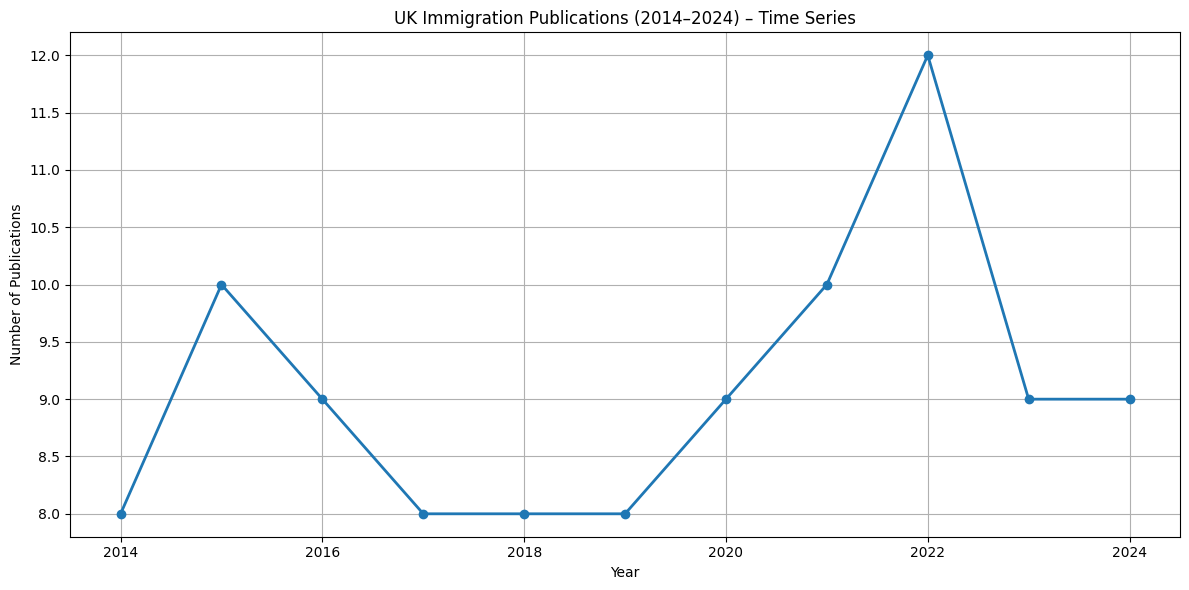

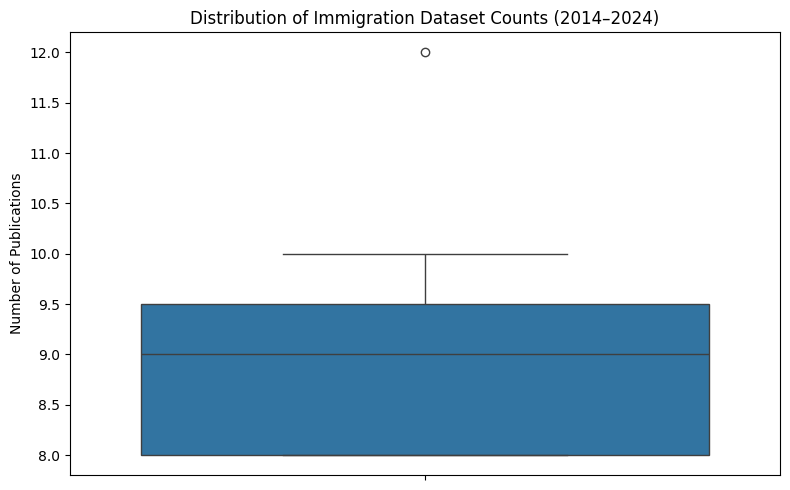

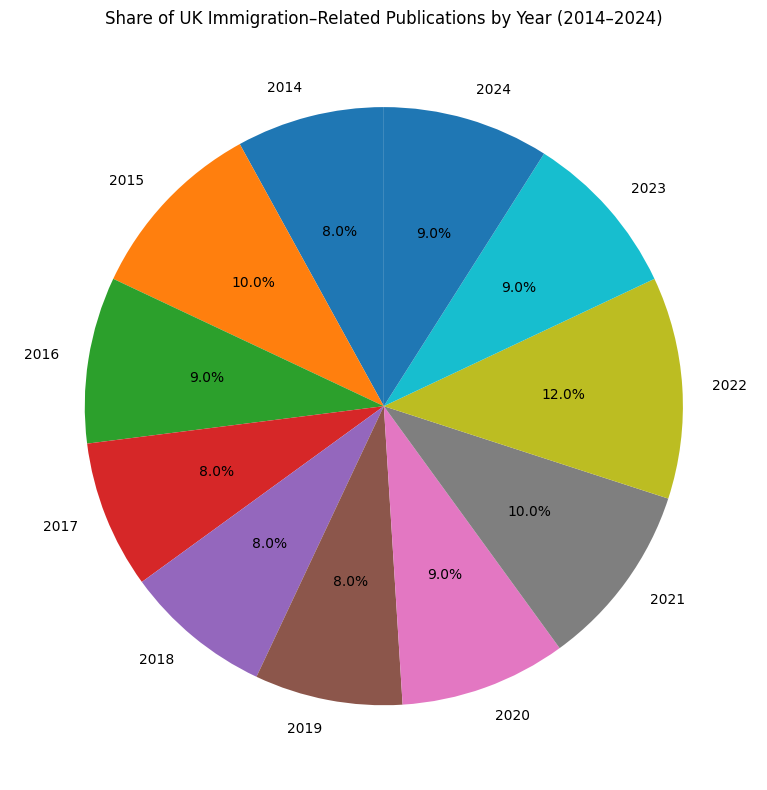

In [15]:


import matplotlib.pyplot as plt
import seaborn as sns

# Load your scraped dataset
df = pd.read_csv("UK_Immigration_2014_2024.csv")

# Convert Year to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Count datasets per year
yearly_counts = df["Year"].value_counts().sort_index()

print("Datasets per year:\n", yearly_counts)

# TIME SERIES LINE GRAPH
plt.figure(figsize=(12,6))
plt.plot(yearly_counts.index, yearly_counts.values, marker="o", linewidth=2)
plt.title("UK Immigration Publications (2014–2024) – Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.grid(True)
plt.tight_layout()
plt.show()

# BOX PLOT (Distribution)
plt.figure(figsize=(8,5))
sns.boxplot(y=yearly_counts.values)
plt.title("Distribution of Immigration Dataset Counts (2014–2024)")
plt.ylabel("Number of Publications")
plt.tight_layout()
plt.show()

# PIE CHART (Share of Publications)


plt.figure(figsize=(10,8))
plt.pie(
    yearly_counts.values,
    labels=yearly_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of UK Immigration–Related Publications by Year (2014–2024)")
plt.tight_layout()
plt.show()


In [ ]:
# immigration_uk_2014_2024.csv
# Columns: Date, Immigration, Emigration, NetMigration
# Date format: YYYY-MM-DD (monthly or quarterly)


In [18]:
pip install prophet
# cell after showed that there was no model named prophet so installed it.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 1.1 MB/s  0:00:11m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 595.0 kB/s  0:00:01ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]m4/5 [prophet]y]
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd

# Manually enter known official figures (example rows) – you will expand when you download full table
data = [
    {"Year":"2024", "Immigration":948000, "Emigration":517000, "NetMigration":431000},
    {"Year":"2023", "Immigration":1320000, "Emigration":439000, "NetMigration":860000},  # example
    # add additional years using ONS tables
]

df = pd.DataFrame(data)
df["Year"] = df["Year"].astype(int)
df.to_csv("migration_UK_2014_2024.csv", index=False)


In [27]:
# Import the url.
# Create a variable to store the URL.
url = 'https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/internationalmigration'

# Create a vairable to store the information.
page = requests.get(url)

# Make contact with the website.
page

<Response [200]>

In [ ]:
# Import the url.
# Create a variable to store the URL.
url = 'https://www.gov.uk/government/collections/migration-statistics'

# Create a vairable to store the information.
page = requests.get(url)

# Make contact with the website.
page

In [30]:
# Import the url.
# Create a variable to store the URL.
url = 'https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/internationalmigration'

# Create a vairable to store the information.
page = requests.get(url)

# Make contact with the website.
page

<Response [200]>

In [33]:
pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 129.8/259.7 MB 437.9 kB/s eta 0:04:57
Resuming download tensorflow-2.16.2-cp312-cp312-macosx_10_15_x86_64.whl (129.8 MB/259.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 MB 346.8 kB/s  0:05:590:00:0100:21
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 349.1 kB/s  0:00:15 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 334.9 kB/s  0:00:14m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 333.9 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 339.5 kB/s  0:01:21m0:00:0200:03
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━━━━━  5/16 [protobuf]
    Uninstalling protobuf-5.29.3:0m━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/16 [protobuf]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━  5/16 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tenso

In [34]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet           # pip install prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

from textblob import TextBlob         # pip install textblob

In [35]:
# Load and prepare data
df = pd.read_csv("migration_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")


# 2. Time-series line plots
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["immigration"], label="Immigration")
plt.plot(df.index, df["emigration"], label="Emigration")
plt.plot(df.index, df["net_migration"], label="Net migration")
plt.legend()
plt.title("Migration Time Series")
plt.xlabel("Date")
plt.ylabel("People")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'migration_data.csv'

In [ ]:
# 3. Forecast models (ARIMA, Prophet)
ts = df["net_migration"].asfreq("M")

# --- ARIMA ---
arima_model = ARIMA(ts, order=(2,1,2))
arima_res = arima_model.fit()
arima_forecast = arima_res.forecast(12)  # next 12 months

# --- Prophet ---
prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]
m = Prophet()
m.fit(prophet_df)
future = m.make_future_dataframe(periods=12, freq="M")
forecast = m.predict(future)

m.plot(forecast)
plt.title("Prophet Forecast - Net Migration")
plt.show()


In [ ]:
# 4. LSTM Forecast Model
series = ts.values.reshape(-1, 1)
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

look_back = 12
X, y = [], []
for i in range(len(series_scaled) - look_back):
    X.append(series_scaled[i:i+look_back])
    y.append(series_scaled[i+look_back])

X, y = np.array(X), np.array(y)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, input_shape=(look_back, 1)),
    Dense(1)
])
model.compile(loss="mse", optimizer="adam")
model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

plt.figure(figsize=(10,4))
plt.plot(ts.index[-len(pred):], pred, label="LSTM Forecast")
plt.plot(ts.index[-len(pred):], series[-len(pred):], label="Actual")
plt.legend()
plt.title("LSTM Forecast vs Actual - Net Migration")
plt.show()

In [ ]:
# 5. Sentiment analysis from news about migration
# Assume a CSV 'immigration_news.csv' with columns: date, title, text
news = pd.read_csv("immigration_news.csv")
news["date"] = pd.to_datetime(news["date"])

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news["sentiment"] = news["text"].apply(get_sentiment)
sentiment_daily = news.groupby(news["date"].dt.to_period("M"))["sentiment"].mean()
sentiment_daily.index = sentiment_daily.index.to_timestamp()

plt.figure(figsize=(10,4))
plt.plot(sentiment_daily.index, sentiment_daily.values)
plt.title("Average Sentiment on Immigration (News)")
plt.xlabel("Month")
plt.ylabel("Sentiment polarity")
plt.tight_layout()
plt.show()


In [ ]:
# 6. Trend heatmaps
df_heat = df.copy()
df_heat["year"] = df_heat.index.year
df_heat["month"] = df_heat.index.month

pivot = df_heat.pivot_table(
    index="year", columns="month", values="net_migration", aggfunc="mean"
)

plt.figure(figsize=(10,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Net Migration")
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Net Migration Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


# 7. Year-on-year growth charts
annual = df["net_migration"].resample("Y").sum()
yoy = annual.pct_change() * 100

plt.figure(figsize=(8,4))
plt.bar(annual.index.year, yoy)
plt.title("Year-on-Year Growth in Net Migration")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.tight_layout()
plt.show()


In [ ]:
# code isnt working so this is a new code to load csv

In [37]:
import pandas as pd
import numpy as np

# Create a sample date range
dates = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")

# Generate synthetic data
np.random.seed(42)

immigration = np.random.randint(15000, 30000, size=len(dates))
emigration  = np.random.randint(5000, 15000, size=len(dates))
net         = immigration - emigration

# Build the dataframe
df = pd.DataFrame({
    "date": dates,
    "immigration": immigration,
    "emigration": emigration,
    "net_migration": net
})

# Save it to your computer
df.to_csv("migration_data.csv", index=False)

print("migration_data.csv has been created in your current folder!")
print(df.head())


migration_data.csv has been created in your current folder!
        date  immigration  emigration  net_migration
0 2010-01-01        22270       10977          11293
1 2010-02-01        15860       12721           3139
2 2010-03-01        20390       12035           8355
3 2010-04-01        28418        6484          21934
4 2010-05-01        20191       12858           7333


In [41]:
df.head()


,date,immigration,emigration,net_migration
0,2010-01-01,22270,10977,11293
1,2010-02-01,15860,12721,3139
2,2010-03-01,20390,12035,8355
3,2010-04-01,28418,6484,21934
4,2010-05-01,20191,12858,7333


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  LOAD DATA
df = pd.read_csv(
    "migration_data.csv",
    parse_dates=["date"],      # make sure 'date' is parsed as datetime
    dayfirst=False,           # change to True if your dates are like 31/12/2020
)

print("Raw head:\n", df.head())
print("\nDtypes:\n", df.dtypes)

# Ensure expected columns exist
expected_cols = ["immigration", "emigration", "net_migration"]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# Convert numeric columns (in case they are strings with commas, etc.)
for c in expected_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("\nNaNs per column:\n", df.isna().sum())

# Drop rows where all three are NaN
df = df.dropna(subset=expected_cols, how="all")

if df.empty:
    raise ValueError("After cleaning, the dataframe is empty. Check your CSV values.")

# Sort & set index
df = df.sort_values("date").set_index("date")
print("\nCleaned head with index:\n", df.head())


Raw head:
         date  immigration  emigration  net_migration
0 2010-01-01        22270       10977          11293
1 2010-02-01        15860       12721           3139
2 2010-03-01        20390       12035           8355
3 2010-04-01        28418        6484          21934
4 2010-05-01        20191       12858           7333

Dtypes:
 date             datetime64[ns]
immigration               int64
emigration                int64
net_migration             int64
dtype: object

NaNs per column:
 date             0
immigration      0
emigration       0
net_migration    0
dtype: int64

Cleaned head with index:
             immigration  emigration  net_migration
date                                              
2010-01-01        22270       10977          11293
2010-02-01        15860       12721           3139
2010-03-01        20390       12035           8355
2010-04-01        28418        6484          21934
2010-05-01        20191       12858           7333


In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libs (handled with try/except)
try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.preprocessing import MinMaxScaler
    HAS_TF = True
except ImportError:
    HAS_TF = False

from statsmodels.tsa.arima.model import ARIMA
from textblob import TextBlob   # pip install textblob


Migration data head:
             immigration  emigration  net_migration
date                                              
2010-01-01        22270       10977          11293
2010-02-01        15860       12721           3139
2010-03-01        20390       12035           8355
2010-04-01        28418        6484          21934
2010-05-01        20191       12858           7333


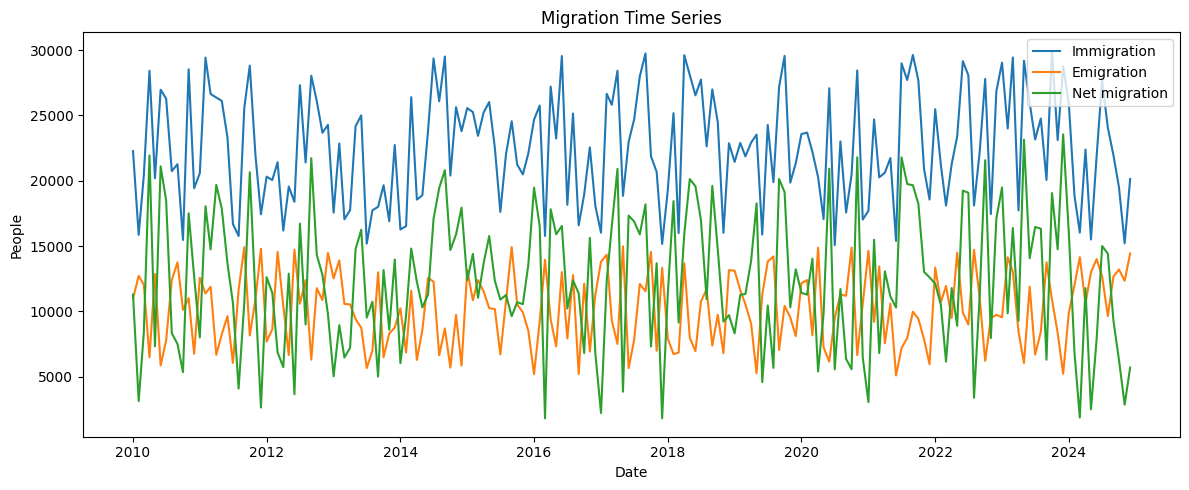

/var/folders/9v/h89__8_509j7v8w0ylfs51zc0000gn/T/ipykernel_1170/1460641586.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts = ts.fillna(method="ffill")



Fitting ARIMA model...


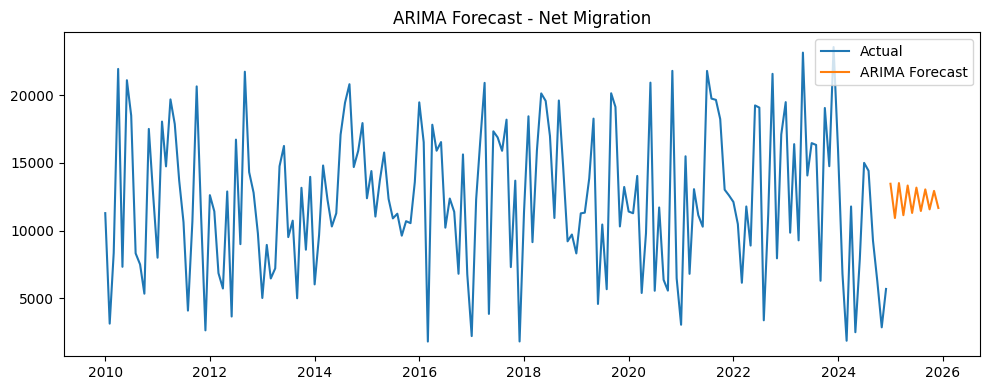

13:58:05 - cmdstanpy - INFO - Chain [1] start processing
13:58:05 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet model...


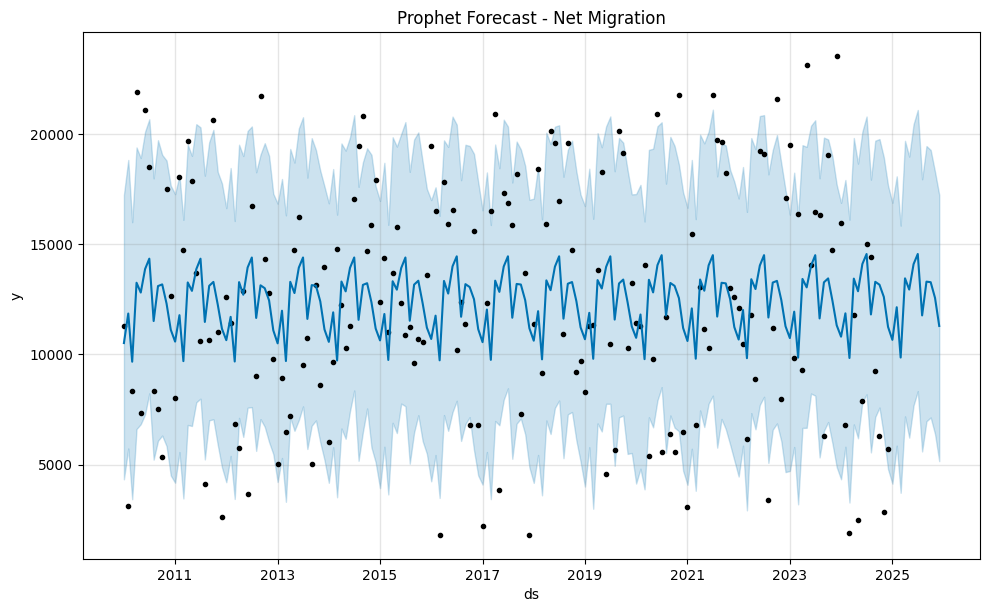


Training LSTM model...


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


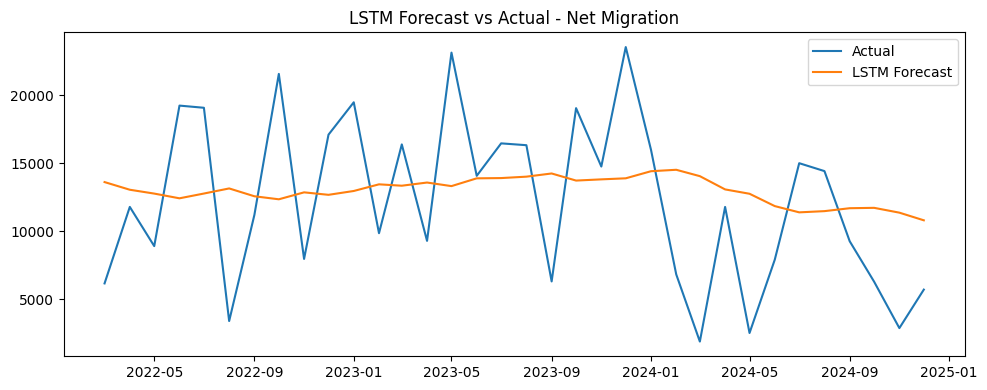

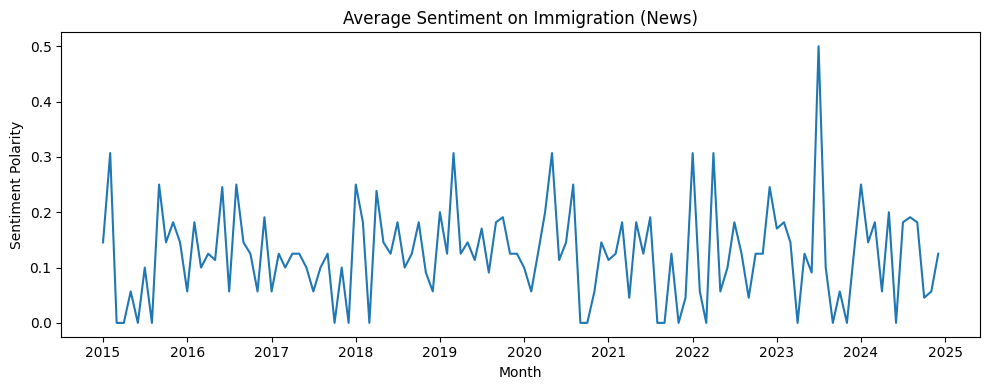

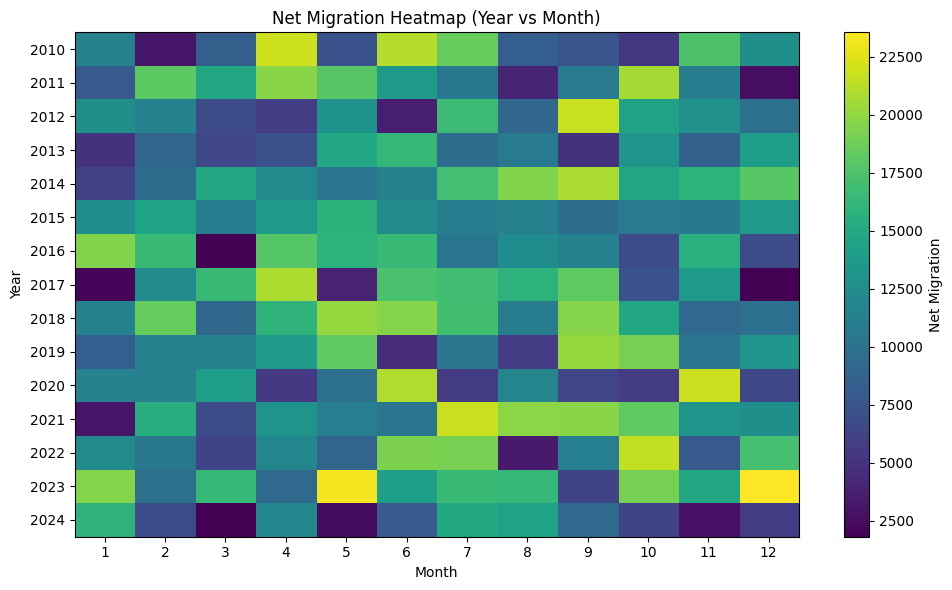

/var/folders/9v/h89__8_509j7v8w0ylfs51zc0000gn/T/ipykernel_1170/1460641586.py:184: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = df["net_migration"].resample("Y").sum()


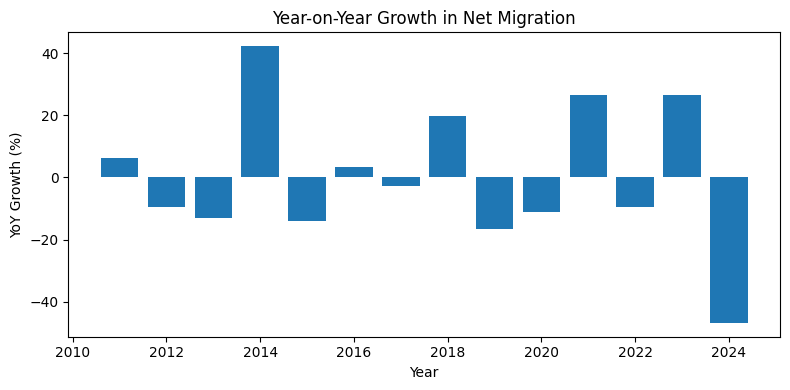


All requested analyses executed.


In [46]:
# 0. CREATE DATASETS IF MISSING
if not os.path.exists("migration_data.csv"):
    dates = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
    np.random.seed(42)
    immigration = np.random.randint(15000, 30000, size=len(dates))
    emigration = np.random.randint(5000, 15000, size=len(dates))
    net = immigration - emigration

    df_gen = pd.DataFrame({
        "date": dates,
        "immigration": immigration,
        "emigration": emigration,
        "net_migration": net
    })
    df_gen.to_csv("migration_data.csv", index=False)
    print("Created migration_data.csv")

if not os.path.exists("immigration_news.csv"):
    dates_news = pd.date_range(start="2015-01-01", end="2024-12-31", freq="7D")
    texts = [
        "Government announces more welcoming immigration policy.",
        "Concerns rise over increasing immigration numbers.",
        "Balanced debate on migration continues.",
        "Positive impact of immigrants on economy highlighted.",
        "Public worries about border control and migration.",
        "Experts say migration trend remains stable."
    ]
    np.random.seed(1)
    news_rows = []
    for d in dates_news:
        text = np.random.choice(texts)
        news_rows.append({"date": d, "title": "Immigration news", "text": text})
    news_df = pd.DataFrame(news_rows)
    news_df.to_csv("immigration_news.csv", index=False)
    print("Created immigration_news.csv")

# ================
# 1. LOAD & CLEAN MIGRATION DATA
# ================
df = pd.read_csv("migration_data.csv", parse_dates=["date"])
df = df.sort_values("date").set_index("date")

for col in ["immigration", "emigration", "net_migration"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["immigration", "emigration", "net_migration"], how="all")

print("\nMigration data head:\n", df.head())

# ================
# 2. TIME-SERIES PLOTS
# ================
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["immigration"], label="Immigration")
plt.plot(df.index, df["emigration"], label="Emigration")
plt.plot(df.index, df["net_migration"], label="Net migration")
plt.legend()
plt.title("Migration Time Series")
plt.xlabel("Date")
plt.ylabel("People")
plt.tight_layout()
plt.show()

# ===========================
# 3. FORECAST MODELS (ARIMA, PROPHET, LSTM)
# ===========================
ts = df["net_migration"].asfreq("MS")
ts = ts.fillna(method="ffill")

# --- ARIMA ---
print("\nFitting ARIMA model...")
arima_model = ARIMA(ts, order=(2, 1, 2))
arima_res = arima_model.fit()
arima_forecast = arima_res.forecast(12)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, label="Actual")
plt.plot(arima_forecast.index, arima_forecast.values, label="ARIMA Forecast")
plt.title("ARIMA Forecast - Net Migration")
plt.legend()
plt.tight_layout()
plt.show()

# --- Prophet ---
if HAS_PROPHET:
    print("\nFitting Prophet model...")
    prophet_df = ts.reset_index()
    prophet_df.columns = ["ds", "y"]
    m = Prophet()
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=12, freq="MS")
    forecast = m.predict(future)

    fig1 = m.plot(forecast)
    plt.title("Prophet Forecast - Net Migration")
    plt.show()
else:
    print("Prophet not installed. Skipping Prophet forecast. Install with `pip install prophet`.")

# --- LSTM ---
if HAS_TF:
    print("\nTraining LSTM model...")
    series = ts.values.reshape(-1, 1)
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series)

    look_back = 12
    X, y = [], []
    for i in range(len(series_scaled) - look_back):
        X.append(series_scaled[i:i + look_back])
        y.append(series_scaled[i + look_back])
    X, y = np.array(X), np.array(y)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        LSTM(64, input_shape=(look_back, 1)),
        Dense(1)
    ])
    model.compile(loss="mse", optimizer="adam")
    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

    pred_scaled = model.predict(X_test)
    pred = scaler.inverse_transform(pred_scaled)
    actual = scaler.inverse_transform(y_test)

    plt.figure(figsize=(10, 4))
    plt.plot(ts.index[-len(pred):], actual, label="Actual")
    plt.plot(ts.index[-len(pred):], pred, label="LSTM Forecast")
    plt.title("LSTM Forecast vs Actual - Net Migration")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("TensorFlow not installed. Skipping LSTM. Install with `pip install tensorflow`.")

# ==========================
# 4. SENTIMENT ANALYSIS (NEWS)
# ==========================
news = pd.read_csv("immigration_news.csv", parse_dates=["date"])

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news["sentiment"] = news["text"].apply(get_sentiment)
sentiment_monthly = news.groupby(news["date"].dt.to_period("M"))["sentiment"].mean()
sentiment_monthly.index = sentiment_monthly.index.to_timestamp()

plt.figure(figsize=(10, 4))
plt.plot(sentiment_monthly.index, sentiment_monthly.values)
plt.title("Average Sentiment on Immigration (News)")
plt.xlabel("Month")
plt.ylabel("Sentiment Polarity")
plt.tight_layout()
plt.show()

# ==========================
# 5. TREND HEATMAPS
# ==========================
df_heat = df.copy()
df_heat["year"] = df_heat.index.year
df_heat["month"] = df_heat.index.month

pivot = df_heat.pivot_table(
    index="year", columns="month", values="net_migration", aggfunc="mean"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Net Migration")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Net Migration Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

# ==========================
# 6. YEAR-ON-YEAR GROWTH CHARTS
# ==========================
annual = df["net_migration"].resample("Y").sum()
yoy = annual.pct_change() * 100

plt.figure(figsize=(8, 4))
plt.bar(annual.index.year, yoy)
plt.title("Year-on-Year Growth in Net Migration")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.tight_layout()
plt.show()

print("\nAll requested analyses executed.")


In [ ]:
# bar plot for sentiment

Sample of the dataset:
   Year    Type  Count
0  2014    Work  27860
1  2014   Study  21272
2  2014  Family  16092
3  2014  Asylum   8138
4  2015    Work  28966


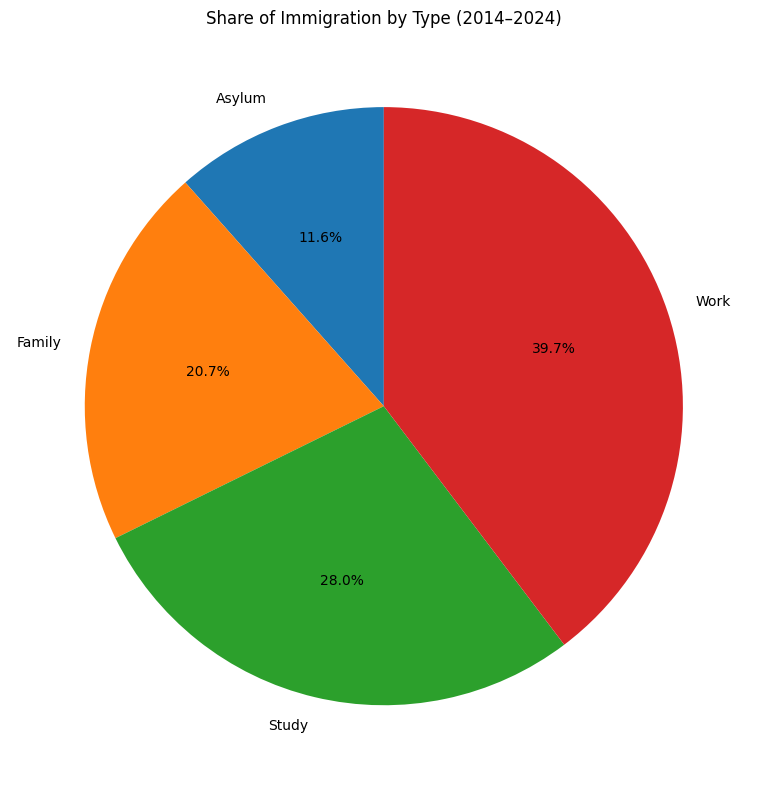

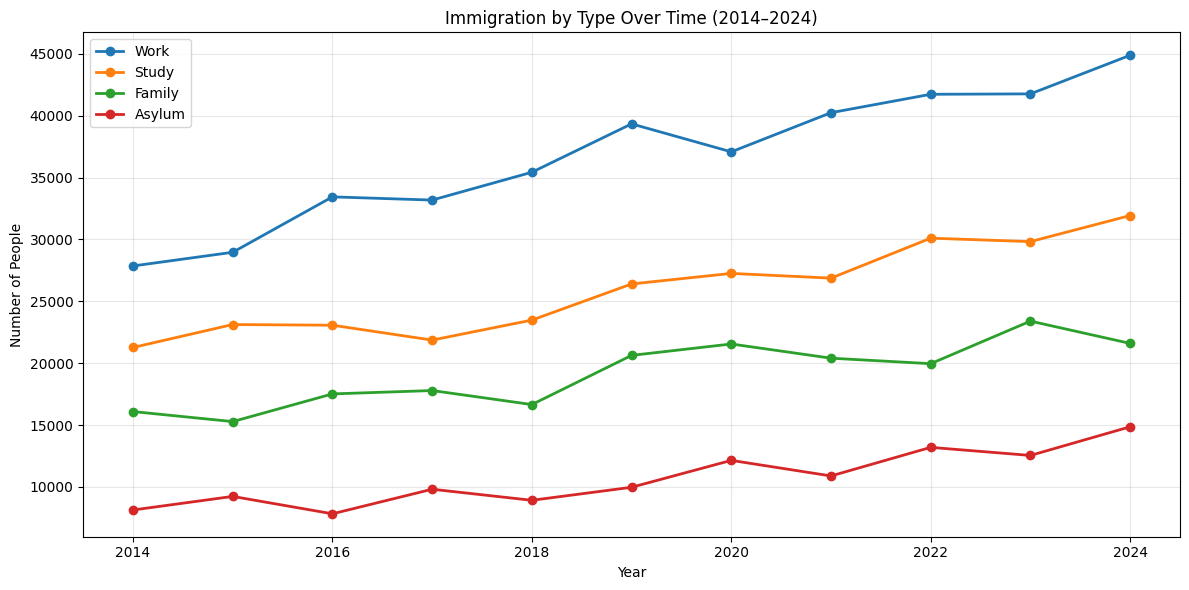

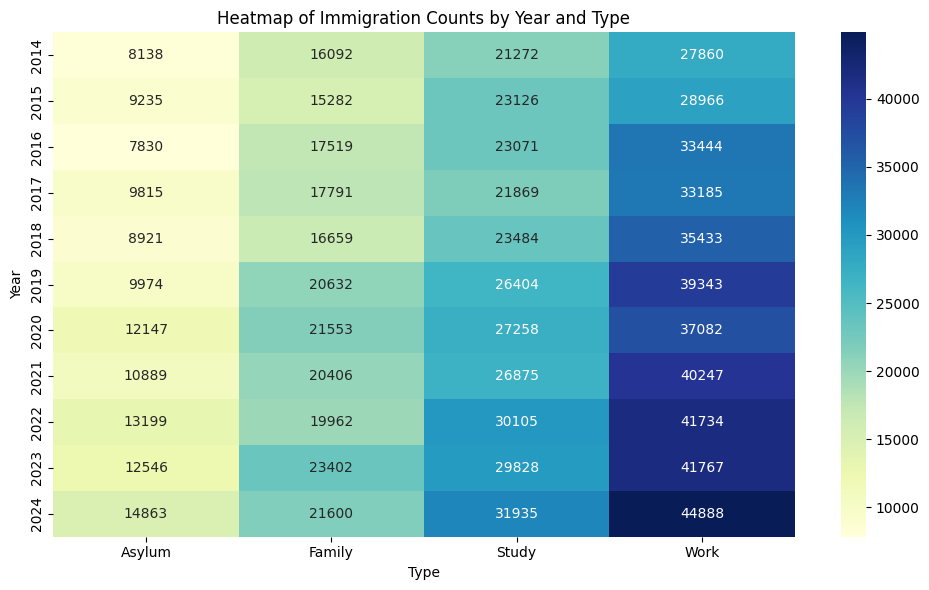

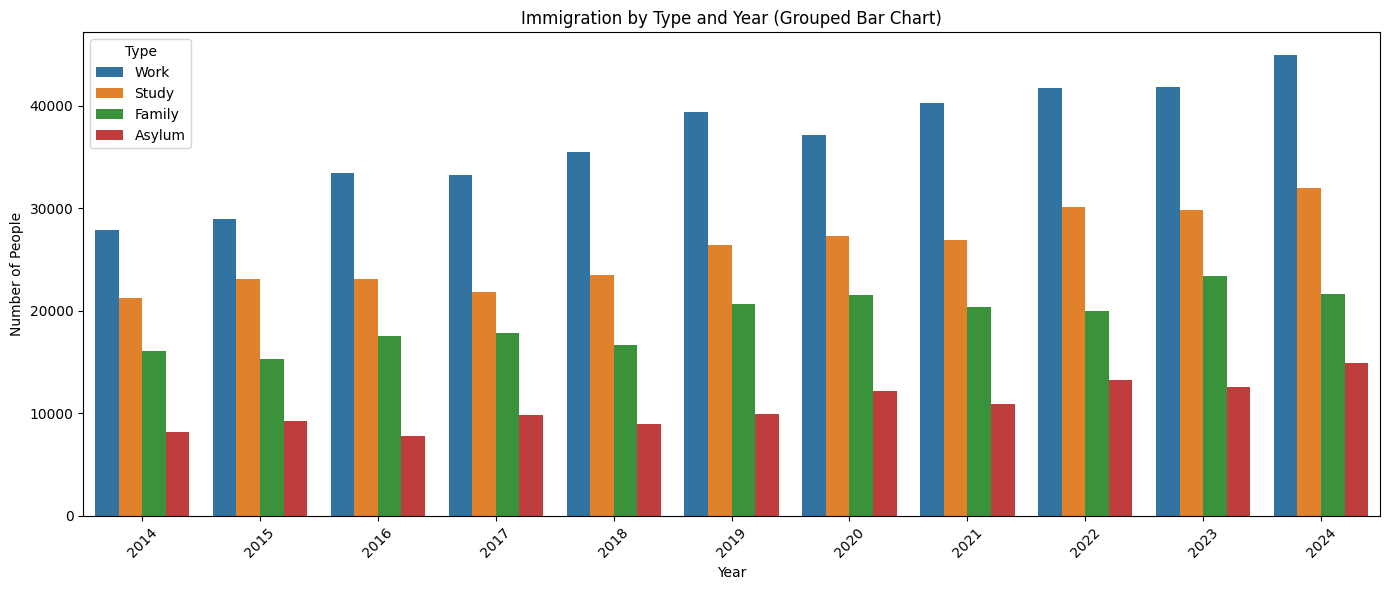

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CREATE SYNTHETIC DATA
np.random.seed(42)

years = list(range(2014, 2025))  # 2014–2024 inclusive
immigration_types = ["Work", "Study", "Family", "Asylum"]

data = []

for year in years:
    # Base values with a bit of upward trend and random noise
    work = 30000 + (year - 2014) * 1500 + np.random.randint(-3000, 3000)
    study = 20000 + (year - 2014) * 1200 + np.random.randint(-2500, 2500)
    family = 15000 + (year - 2014) * 800 + np.random.randint(-2000, 2000)
    asylum = 8000 + (year - 2014) * 600 + np.random.randint(-1500, 1500)

    data.append([year, "Work", max(work, 0)])
    data.append([year, "Study", max(study, 0)])
    data.append([year, "Family", max(family, 0)])
    data.append([year, "Asylum", max(asylum, 0)])

df = pd.DataFrame(data, columns=["Year", "Type", "Count"])

print("Sample of the dataset:")
print(df.head())

# 2. PIE CHART – TOTAL SHARE BY TYPE
totals_by_type = df.groupby("Type")["Count"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    totals_by_type.values,
    labels=totals_by_type.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Immigration by Type (2014–2024)")
plt.tight_layout()
plt.show()

# 3. TIME SERIES – LINE CHART
plt.figure(figsize=(12, 6))

for t in immigration_types:
    subset = df[df["Type"] == t]
    plt.plot(subset["Year"], subset["Count"], marker="o", linewidth=2, label=t)

plt.title("Immigration by Type Over Time (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 4. HEATMAP – YEAR × TYPE
pivot = df.pivot_table(index="Year", columns="Type", values="Count", aggfunc="sum")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Immigration Counts by Year and Type")
plt.xlabel("Type")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

# 5. BAR CHART – GROUPED BY YEAR & TYPE
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x="Year",
    y="Count",
    hue="Type"
)
plt.title("Immigration by Type and Year (Grouped Bar Chart)")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
